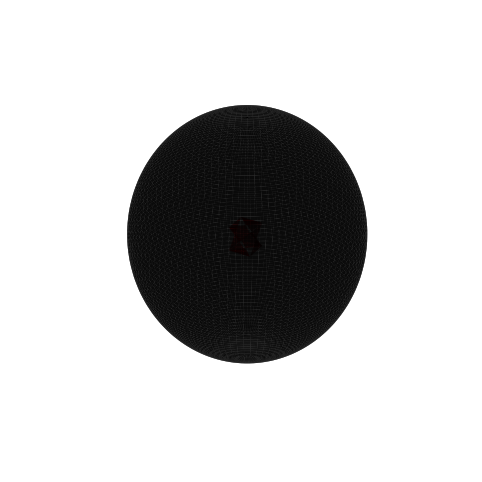

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the phi and theta ranges
phi_min, phi_max = 0*np.pi, 0*np.pi # Phi range in radians
theta_min, theta_max =0*np.pi, 0*np.pi # Theta range in radians

# Create a mesh grid for phi and theta
phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, np.pi, 100)
phi, theta = np.meshgrid(phi, theta)

# Convert spherical to Cartesian coordinates
r = 1  # Radius of the sphere
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

# Create a mask for the specified range
mask = (phi >= phi_min) & (phi <= phi_max) & (theta >= theta_min) & (theta <= theta_max)

# Plot the spherical coordinate system
fig = plt.figure()
fig.set_size_inches(8, 6)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, facecolors=np.where(mask, 'white', 'black'), rstride=1, cstride=1, linewidth=0, antialiased=True, edgecolor='none', alpha=0.8)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1
ax.set_axis_off()

# Define the size of the cube
cube_size = 0.2
shift = np.array([0, -0.3, 0])

# Define the vertices of the cube
cube_vertices = np.array([[0, 0, 0],
                          [cube_size, 0, 0],
                          [cube_size, cube_size, 0],
                          [0, cube_size, 0],
                          [0, 0, cube_size],
                          [cube_size, 0, cube_size],
                          [cube_size, cube_size, cube_size],
                          [0, cube_size, cube_size]]) + shift

# Define the faces of the cube
cube_faces = [[cube_vertices[j] for j in [0, 1, 2, 3]],
              [cube_vertices[j] for j in [4, 5, 6, 7]],
              [cube_vertices[j] for j in [0, 1, 5, 4]],
              [cube_vertices[j] for j in [2, 3, 7, 6]],
              [cube_vertices[j] for j in [1, 2, 6, 5]],
              [cube_vertices[j] for j in [4, 7, 3, 0]]]

# Plot the cube
for face in cube_faces:
    ax.plot_surface(np.array([vertex[0] for vertex in face]).reshape(2, 2),
                    np.array([vertex[1] for vertex in face]).reshape(2, 2),
                    np.array([vertex[2] for vertex in face]).reshape(2, 2),
                    color='red', edgecolor='none', alpha=0.7)

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

plt.show()